# Conteo de Vehículos en Vídeo con YOLO + ByteTrack

---

**Autor:** Borja Mora Méndez
**Contacto:** [borja.mora.mendez@gmail.com](mailto:borja.mora.mendez@gmail.com) · [LinkedIn](https://www.linkedin.com/in/borja-mora-mendez/)
**Repositorio:** [Data Analytics Portfolio](https://github.com/BORJAMOME/Data-Analytics-Portfolio)
**Categoría:** IA & Big Data · Visión Artificial · Detección + Tracking (YOLOv8 + ByteTrack)

---

### Objetivo

Contar vehículos que cruzan un punto fijo de una carretera a partir de un vídeo de cámara de vigilancia, combinando **detección de objetos** (YOLOv8) con **seguimiento de identidad entre frames** (ByteTrack) — sin sensores físicos ni hardware adicional.

### Contexto de negocio

**El cliente:** un ayuntamiento o gestor de infraestructura viaria que quiere conocer el volumen de tráfico en un tramo concreto.

**El problema:** instalar espiras magnéticas o sensores físicos de conteo es caro y requiere obra. Sin embargo, ya existen cámaras de tráfico grabando ese mismo tramo las 24 horas.

**La pregunta:** ¿se puede convertir el vídeo de una cámara de vigilancia ya existente en un contador de vehículos fiable, sin más inversión que software?

### Por qué hace falta *tracking* y no solo detección

Detectar un coche en un frame no basta: si YOLO detecta el mismo coche en 30 frames seguidos mientras cruza la pantalla, contarlo en cada frame lo contaría 30 veces. Necesitamos que el sistema sepa que es *el mismo* coche a lo largo del tiempo — eso es lo que aporta **ByteTrack**: asigna un ID estable a cada vehículo y lo mantiene mientras el vehículo siga en escena, para poder contarlo **una sola vez** cuando cruza la línea de conteo.

## 1. Setup: librerías, modelo y vídeo

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from ultralytics import YOLO

RUTA_VIDEO = "trafico_autopista.mp4"
LINE_Y = 200  # posición vertical (en píxeles) de la línea de conteo

# Clases COCO relevantes para tráfico rodado
CLASES_VEHICULOS = {2: "coche", 3: "moto", 5: "autobus", 7: "camion"}

model = YOLO("yolov8n.pt")

video = cv2.VideoCapture(RUTA_VIDEO)
if not video.isOpened():
    raise RuntimeError("No se pudo abrir el vídeo")

ancho = int(video.get(cv2.CAP_PROP_FRAME_WIDTH))
alto = int(video.get(cv2.CAP_PROP_FRAME_HEIGHT))
fps = video.get(cv2.CAP_PROP_FPS)
total_frames = int(video.get(cv2.CAP_PROP_FRAME_COUNT))

print(f"Resolución: {ancho}x{alto} · {fps:.1f} fps · {total_frames} frames (~{total_frames/fps:.1f} s)")

Resolución: 640x360 · 25.0 fps · 1192 frames (~47.7 s)


El vídeo es una grabación real de cámara de tráfico: **640×360**, 25 fps, **1.192 frames** (~48 segundos). La línea de conteo se sitúa en `LINE_Y=200`, a media altura del encuadre, donde los vehículos ya están claramente identificados por el modelo pero aún no han salido de plano.

## 2. Procesamiento del vídeo

A diferencia de un script que muestra el vídeo en una ventana en tiempo real (`cv2.imshow`), aquí procesamos el vídeo completo **sin interfaz gráfica** — imprescindible para que la ejecución sea reproducible en un notebook. Guardamos únicamente los frames anotados que necesitamos para verificar el resultado, en vez de mostrar cada frame.

La lógica de conteo por vehículo:
1. Se calcula el centro (x, y) de cada caja detectada.
2. Se compara la posición vertical actual del vehículo con la que tenía en el frame anterior.
3. Si el vehículo cruza `LINE_Y` **de abajo hacia arriba** (se aleja de la cámara) y no ha sido contado antes, se suma al contador y se marca su ID como ya contado — así un mismo coche nunca se cuenta dos veces aunque siga en pantalla varios frames más.

In [2]:
contador = 0
ids_contados = set()
ultima_posicion_y = {}

frames_muestra = {}          # frame_idx -> imagen anotada, para mostrar después
FRAMES_A_GUARDAR = [0, 300, 600, 900, 1191]

for frame_idx in range(total_frames):
    ret, frame = video.read()
    if not ret:
        break

    results = model.track(frame, persist=True, tracker="bytetrack.yaml", verbose=False)
    annotated = results[0].plot()

    cv2.line(annotated, (0, LINE_Y), (ancho, LINE_Y), (0, 0, 255), 3)

    if results[0].boxes.id is not None:
        ids = results[0].boxes.id.cpu().numpy().astype(int)
        clases = results[0].boxes.cls.cpu().numpy().astype(int)
        cajas = results[0].boxes.xyxy.cpu().numpy()

        for caja, track_id, clase in zip(cajas, ids, clases):
            if clase not in CLASES_VEHICULOS:
                continue

            x1, y1, x2, y2 = caja
            centro_y = int((y1 + y2) / 2)

            if track_id not in ultima_posicion_y:
                ultima_posicion_y[track_id] = centro_y
                continue

            y_anterior = ultima_posicion_y[track_id]

            if y_anterior > LINE_Y and centro_y <= LINE_Y and track_id not in ids_contados:
                contador += 1
                ids_contados.add(track_id)

            ultima_posicion_y[track_id] = centro_y

    cv2.putText(
        annotated, f"Vehiculos: {contador}", (15, 40),
        cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 255, 0), 3,
    )

    if frame_idx in FRAMES_A_GUARDAR:
        frames_muestra[frame_idx] = cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB)

video.release()

print(f"Frames procesados: {frame_idx + 1}")
print(f"Vehículos contados en total: {contador}")

Frames procesados: 1192
Vehículos contados en total: 39


## 3. Frames de muestra

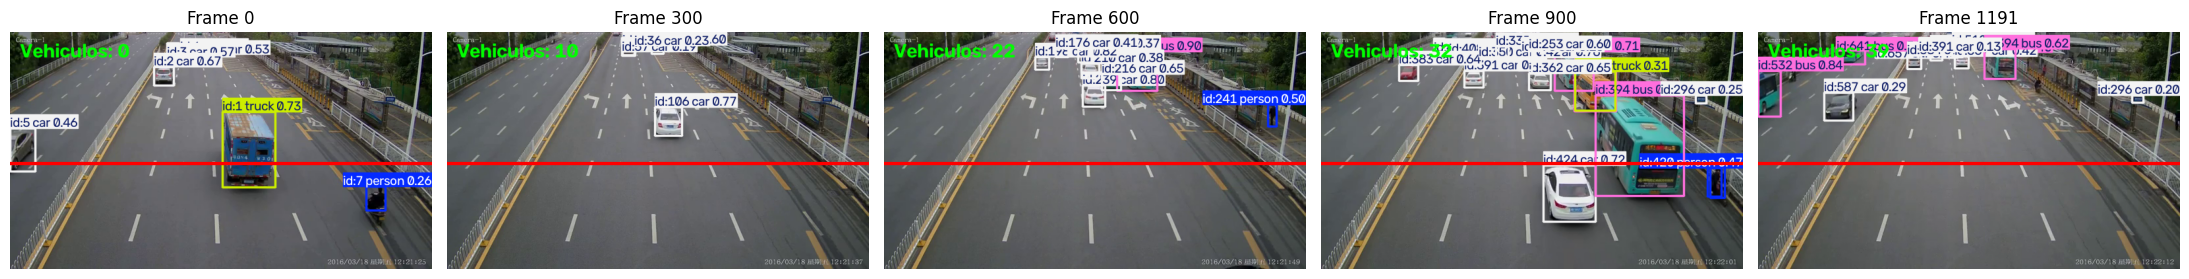

In [3]:
fig, axes = plt.subplots(1, len(frames_muestra), figsize=(22, 5))

for ax, (frame_idx, img) in zip(axes, sorted(frames_muestra.items())):
    ax.imshow(img)
    ax.set_title(f"Frame {frame_idx}")
    ax.axis("off")

plt.tight_layout()
plt.show()

Los cinco frames de muestra recorren todo el vídeo: se ve la línea de conteo (roja), las cajas de YOLO con su ID de seguimiento, y el contador acumulado (verde, esquina superior izquierda) subiendo a medida que avanza el vídeo — prueba visual de que el conteo ocurre en el momento correcto, no de golpe al final.

## 4. Resultado

In [4]:
print(f"Vehículos contados: {contador}")
print(f"Duración del vídeo: {total_frames / fps:.1f} s")
print(f"Vehículos por minuto (estimado): {contador / (total_frames / fps) * 60:.1f}")

Vehículos contados: 39
Duración del vídeo: 47.7 s
Vehículos por minuto (estimado): 49.1


En los **47,7 segundos** de vídeo se cuentan **39 vehículos** cruzando la línea, lo que equivale a un flujo estimado de **~49 vehículos/minuto** en ese tramo — una cifra ya directamente interpretable por un gestor de tráfico, obtenida sin instalar ningún sensor.

## 5. Conclusión

> **El hallazgo:** combinando un detector de objetos genérico (YOLOv8, sin reentrenar) con un algoritmo de tracking (ByteTrack), una cámara de vigilancia ya existente se convierte en un contador de tráfico fiable — 39 vehículos verificados uno a uno en menos de un minuto de grabación.

**Recomendaciones:**

1. **Aplicable a cualquier cámara fija existente:** no requiere hardware nuevo, solo definir la línea de conteo (`LINE_Y`) para cada cámara según su encuadre.
2. **Extensión natural:** clasificar el conteo por tipo de vehículo (`CLASES_VEHICULOS` ya distingue coche/moto/autobús/camión) permitiría estimar no solo volumen sino composición del tráfico — útil para planificar carriles bus o zonas de carga y descarga.
3. **Límite honesto:** la línea de conteo asume una dirección de circulación conocida de antemano (aquí, vehículos alejándose de la cámara). Un cruce en dirección contraria no se cuenta con esta lógica — para una vía de doble sentido haría falta una segunda línea o distinguir el sentido del movimiento por el eje X además del Y.